*** 1. Problem Definition ***

We aim to predict the wildfire events likelihood that the fire comes within 5 km of an evacuation zone at different future time horizon: [prob_12h prob_24h prob_48h prob_72h]


Target Y:  
* time_to_hit_hours = time until the wildfire reaches the zone
* event(wildfire) = 1 if it reached, 0 if censored

Feature X: test and train data columns


Our goal is to imporve the metrics:  
* HybridScore = 0.3 × C-inde x+ 0.7 × (1 − Weighted Brier Score)

In [16]:
import pandas as pd
import numpy as np

# Load Data
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

# check data stucture
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (221, 37)
Test shape: (95, 35)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [17]:
# Check missing vals
missing_train = train.isnull().sum().sum()
missing_test = test.isnull().sum().sum()

print("Total missing values in train:", missing_train)
print("Total missing values in test:", missing_test)

Total missing values in train: 0
Total missing values in test: 0


In [18]:
# raw Feature columns (exclude ID and target variables)
FEATURE_COLS = [
    col for col in train.columns
    if col not in ["event_id", "time_to_hit_hours", "event"]
]

X = train[FEATURE_COLS]
X_test = test[FEATURE_COLS]

print("Total number of features:", len(FEATURE_COLS))

Total number of features: 34


In [19]:
train.shape
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


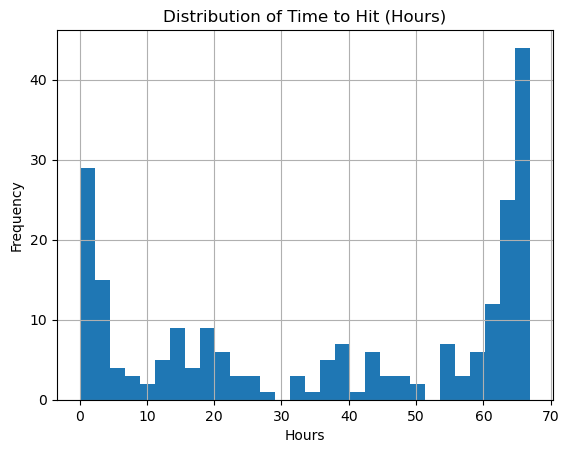

In [20]:
# Visualize 
import matplotlib.pyplot as plt

train["time_to_hit_hours"].hist(bins=30)
plt.title("Distribution of Time to Hit (Hours)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()


### 2. DATA UNDERSTANDING AND AUDIT



In [21]:
# some basic stats on the datasets
# Event distribution
print(f"\nEvent distribution:")
event_counts = train["event"].value_counts().sort_index()
print(f"  Censored (0): {event_counts.get(0, 0)} ({event_counts.get(0, 0)/len(train)*100:.1f}%)")
print(f"  Hit (1): {event_counts.get(1, 0)} ({event_counts.get(1, 0)/len(train)*100:.1f}%)")

# Time to hit stats (for events that hit)
hits = train[train["event"] == 1]
print(f"\nTime-to-hit distribution (hits only, n={len(hits)}):")
print(f"  Mean: {hits['time_to_hit_hours'].mean():.1f}h")
print(f"  Median: {hits['time_to_hit_hours'].median():.1f}h")
print(f"  Min: {hits['time_to_hit_hours'].min():.1f}h")
print(f"  Max: {hits['time_to_hit_hours'].max():.1f}h")
print(f"  25th: {hits['time_to_hit_hours'].quantile(0.25):.1f}h")
print(f"  75th: {hits['time_to_hit_hours'].quantile(0.75):.1f}h")

# Horizon feasibility
print(f"\nHits by horizon (feasibility check):")
for h in [12, 24, 48, 72]:
    n_hits = ((train["time_to_hit_hours"] <= h) & (train["event"] == 1)).sum()
    print(f"  ≤{h:2d}h: {n_hits:3d} hits ({n_hits/len(train)*100:.1f}% of dataset)")



Event distribution:
  Censored (0): 152 (68.8%)
  Hit (1): 69 (31.2%)

Time-to-hit distribution (hits only, n=69):
  Mean: 10.0h
  Median: 3.5h
  Min: 0.0h
  Max: 66.9h
  25th: 0.9h
  75th: 14.3h

Hits by horizon (feasibility check):
  ≤12h:  49 hits (22.2% of dataset)
  ≤24h:  63 hits (28.5% of dataset)
  ≤48h:  66 hits (29.9% of dataset)
  ≤72h:  69 hits (31.2% of dataset)


In [22]:
# Missing values audit
FEATURE_COLS = [col for col in train.columns 
                if col not in ["event_id", "time_to_hit_hours", "event"]]

missing_train = train[FEATURE_COLS].isnull().sum()
missing_test = test[FEATURE_COLS].isnull().sum()

if missing_train.sum() == 0:
    print("\nNo missing values in training features.")
else:
    print("\nMissing values in training features:")
    print(missing_train[missing_train > 0].sort_values(ascending=False))

if missing_test.sum() == 0:
    print("\nNo missing values in test features.")
else:
    print("\nMissing values in test features:")
    print(missing_test[missing_test > 0].sort_values(ascending=False))
    
# check for duplicates
n_dup = train.duplicated(subset=FEATURE_COLS).sum()
print(f"\nNumber of duplicate rows in training data: {n_dup}")


No missing values in training features.

No missing values in test features.

Number of duplicate rows in training data: 0


In [23]:
# data leakage check, features that are highly correlated with the target
# Correlation with target time (suspicious if too high)
print("\nTop 10 features correlated with time_to_hit:")
correlations = train[FEATURE_COLS].corrwith(train["time_to_hit_hours"]).abs()
top_corr = correlations.sort_values(ascending=False).head(10)
for col, corr in top_corr.items():
    flag = "WARNING " if corr > 0.7 else "  "
    print(f"{flag} {col:40s}: {corr:.3f}")

# Perfect separation check
print("\nChecking for perfect event separation:")
n_perfect = 0
for col in FEATURE_COLS:
    hit_min = train[train["event"] == 1][col].min()
    cens_max = train[train["event"] == 0][col].max()
    if hit_min > cens_max:
        print(f"{col}: Hits always > Censored")
        n_perfect += 1
        
if n_perfect == 0:
    print("No perfect separation found")


Top 10 features correlated with time_to_hit:
   low_temporal_resolution_0_5h            : 0.442
   dt_first_last_0_5h                      : 0.435
   num_perimeters_0_5h                     : 0.392
   spread_bearing_cos                      : 0.370
   alignment_abs                           : 0.367
   spread_bearing_deg                      : 0.336
   dist_min_ci_0_5h                        : 0.325
   log1p_growth                            : 0.317
   dist_fit_r2_0_5h                        : 0.284
   log_area_ratio_0_5h                     : 0.228

Checking for perfect event separation:
No perfect separation found


In [24]:
# outliers - flag extreme outliers (5 IQR rule)
outlier_features = []
for col in FEATURE_COLS:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 5 * IQR
    upper = Q3 + 5 * IQR
    
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    pct_outliers = n_outliers / len(train) * 100
    
    if pct_outliers > 5:  # Only flag if >5% are outliers
        outlier_features.append((col, n_outliers, pct_outliers))

if outlier_features:
    print(f"\nFeatures with >5% extreme outliers:")
    for col, n, pct in sorted(outlier_features, key=lambda x: x[2], reverse=True)[:10]:
        print(f"   {col:40s}: {n:3d} ({pct:5.1f}%)")
else:
    print("\nNo features with >5% extreme outliers")



Features with >5% extreme outliers:
   alignment_cos                           :  61 ( 27.6%)
   dist_slope_ci_0_5h                      :  52 ( 23.5%)
   alignment_abs                           :  45 ( 20.4%)
   dist_accel_m_per_h2                     :  35 ( 15.8%)
   area_growth_abs_0_5h                    :  25 ( 11.3%)
   area_growth_rel_0_5h                    :  25 ( 11.3%)
   area_growth_rate_ha_per_h               :  25 ( 11.3%)
   log_area_ratio_0_5h                     :  25 ( 11.3%)
   relative_growth_0_5h                    :  25 ( 11.3%)
   radial_growth_m                         :  25 ( 11.3%)


### 3. DATA PREP:

In [25]:
def feature_engineering(df):
    df = df.copy()
    eps = 1e-6

    dist = df["dist_min_ci_0_5h"].clip(lower=1)
    dist_km = dist / 1000.0

    closing = df["closing_speed_m_per_h"]
    radial = df["radial_growth_rate_m_per_h"]

    df["log_distance"] = np.log1p(dist)
    df["dist_km"] = dist_km
    df["inv_distance"] = 1.0 / (dist_km + 0.1)

    df["eta_hours"] = dist / np.maximum(closing, eps)
    df["eta_effective"] = dist / np.maximum(closing + radial, eps)

    fire_area_m2 = df["area_first_ha"] * 10000.0
    df["fire_radius_est"] = np.sqrt(fire_area_m2 / np.pi)
    df["radius_to_distance"] = df["fire_radius_est"] / np.maximum(dist, eps)

    df["threat_score"] = df["alignment_abs"] * closing / np.log1p(dist)
    df["zone_critical"] = (dist < 5000).astype(int)
    
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df

train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

FEATURE_COLS = [c for c in train_fe.columns if c not in ["event_id", "time_to_hit_hours", "event"]]
print("Total features (with engineered):", len(FEATURE_COLS))

Total features (with engineered): 43


### 5. Baseline modeling:

In [26]:
# double checking feature list after all transformations
print(f"Feature count: {len(FEATURE_COLS)}")
for i, col in enumerate(sorted(FEATURE_COLS), 1):
    print(f"{i:2d}. {col}")

Feature count: 43
 1. alignment_abs
 2. alignment_cos
 3. along_track_speed
 4. area_first_ha
 5. area_growth_abs_0_5h
 6. area_growth_rate_ha_per_h
 7. area_growth_rel_0_5h
 8. centroid_displacement_m
 9. centroid_speed_m_per_h
10. closing_speed_abs_m_per_h
11. closing_speed_m_per_h
12. cross_track_component
13. dist_accel_m_per_h2
14. dist_change_ci_0_5h
15. dist_fit_r2_0_5h
16. dist_km
17. dist_min_ci_0_5h
18. dist_slope_ci_0_5h
19. dist_std_ci_0_5h
20. dt_first_last_0_5h
21. eta_effective
22. eta_hours
23. event_start_dayofweek
24. event_start_hour
25. event_start_month
26. fire_radius_est
27. inv_distance
28. log1p_area_first
29. log1p_growth
30. log_area_ratio_0_5h
31. log_distance
32. low_temporal_resolution_0_5h
33. num_perimeters_0_5h
34. projected_advance_m
35. radial_growth_m
36. radial_growth_rate_m_per_h
37. radius_to_distance
38. relative_growth_0_5h
39. spread_bearing_cos
40. spread_bearing_deg
41. spread_bearing_sin
42. threat_score
43. zone_critical


In [30]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import StratifiedKFold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
import warnings
warnings.filterwarnings("ignore")

# Survival-aware helpers
HORIZONS = [12, 24, 48, 72]

def y_horizon(df, H):
    if H == 72:
        return df["event"].astype(int)
    return ((df["event"] == 1) & (df["time_to_hit_hours"] <= H)).astype(int)

def known_mask(df, H):
    if H == 72:
        return np.ones(len(df), dtype=bool)
    return ~((df["event"] == 0) & (df["time_to_hit_hours"] < H))

def weighted_brier(df, probs_df, horizons=(24, 48, 72), weights={24:0.3, 48:0.4, 72:0.3}):
    briers = {}
    for H in horizons:
        col = f"prob_{H}h"
        m = known_mask(df, H)
        y_true = y_horizon(df, H)[m]
        y_pred = probs_df.loc[m, col]
        briers[H] = brier_score_loss(y_true, y_pred)
    wb = sum(weights[H] * briers[H] for H in horizons)
    return wb, briers

def enforce_monotonic(df_probs):
    out = df_probs.copy()
    out["prob_24h"] = np.maximum(out["prob_24h"], out["prob_12h"])
    out["prob_48h"] = np.maximum(out["prob_48h"], out["prob_24h"])
    out["prob_72h"] = np.maximum(out["prob_72h"], out["prob_48h"])
    return out.clip(0, 1)

# ----------------------
# RSF helper func for predicting horizons 
# ----------------------
def rsf_predict_horizons(rsf, X, horizons):
    """Extract probabilities with safe horizon handling"""
    surv_funcs = rsf.predict_survival_function(X, return_array=False)
    
    preds = {}
    for H in horizons:
        prob = []
        for sf in surv_funcs:
            max_time = sf.domain[1]  # Get max time this function covers
            H_safe = min(H, max_time)  # clip horizon 
            prob.append(1 - sf(H_safe))
        preds[f"prob_{H}h"] = np.array(prob)
        
    return pd.DataFrame(preds, index=X.index)
# -----------------------------
# v2 Seed Bagging Config
# -----------------------------
SEEDS = list(range(42, 52))
BEST_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=3,
    num_leaves=11,
    min_child_samples=30,
    reg_lambda=2.0
)

test_sum = pd.DataFrame(0.0, index=test_fe.index, columns=[f"prob_{H}h" for H in HORIZONS])
seed_scores = []

for seed in SEEDS:
    print(f"\n===== SEED {seed} =====")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    oof_raw = pd.DataFrame(0.0, index=train_fe.index, columns=[f"prob_{H}h" for H in HORIZONS])
    test_raw = pd.DataFrame(0.0, index=test_fe.index, columns=[f"prob_{H}h" for H in HORIZONS])

    for H in HORIZONS:
        col = f"prob_{H}h"

        m = known_mask(train_fe, H)
        XH = train_fe.loc[m, FEATURE_COLS]
        yH = y_horizon(train_fe, H).loc[m]

        for fold, (tr_idx, va_idx) in enumerate(cv.split(XH, yH), 1):
            X_tr, X_va = XH.iloc[tr_idx], XH.iloc[va_idx]
            y_tr, y_va = yH.iloc[tr_idx], yH.iloc[va_idx]

            model = LGBMClassifier(
                objective="binary",
                subsample=0.9,
                colsample_bytree=0.8,
                random_state=seed + 1000*H + fold,
                n_jobs=-1,
                verbose=-1,
                **BEST_PARAMS
            )

            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="binary_logloss",
                callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
            )

            va_index = XH.index[va_idx]
            oof_raw.loc[va_index, col] = model.predict_proba(X_va)[:, 1]
            test_raw[col] += model.predict_proba(test_fe[FEATURE_COLS])[:, 1] / cv.get_n_splits()

    # Train RSF
    print("Training RSF...")

    y_struct = Surv.from_arrays(
        event=train_fe["event"].astype(bool),
        time=train_fe["time_to_hit_hours"]
    )

    rsf = RandomSurvivalForest(
        n_estimators=300,
        min_samples_split=20,
        min_samples_leaf=15,
        max_depth=6,
        n_jobs=-1,
        random_state=seed
    )

    rsf.fit(train_fe[FEATURE_COLS], y_struct)

    rsf_oof = rsf_predict_horizons(rsf, train_fe[FEATURE_COLS], HORIZONS)
    rsf_test = rsf_predict_horizons(rsf, test_fe[FEATURE_COLS], HORIZONS)
    
    # Blend LGBM + RSF
    alpha = 0.7  # LGBM weight
    oof_blend = alpha * oof_raw + (1 - alpha) * rsf_oof
    test_blend = alpha * test_raw + (1 - alpha) * rsf_test

    # Then calibrate
    oof_cal = oof_blend.copy()
    test_cal = test_blend.copy()

    # isotonic calibration per horizon (fit only on known rows)
    for H in HORIZONS:
        col = f"prob_{H}h"
        m = known_mask(train_fe, H)

        # if H == 72:
        #     # Skip isotonic at 72h (prevents overfitting)
        #     oof_cal[col] = oof_raw[col]
        #     test_cal[col] = test_raw[col]
        # else:
        #     iso = IsotonicRegression(out_of_bounds="clip")
        #     iso.fit(oof_raw.loc[m, col], y_horizon(train_fe, H).loc[m])
        #     oof_cal[col] = iso.transform(oof_raw[col])
        #     test_cal[col] = iso.transform(test_raw[col])
        if H != 72:
            iso = IsotonicRegression(out_of_bounds="clip")
            iso.fit(oof_raw.loc[m, col], y_horizon(train_fe, H).loc[m])
            oof_cal[col] = iso.transform(oof_raw[col])
            test_cal[col] = iso.transform(test_raw[col])
    
   
    oof_cal = enforce_monotonic(oof_cal)
    test_cal = enforce_monotonic(test_cal)

    wb, briers = weighted_brier(train_fe, oof_cal)
    seed_scores.append(wb)
    print("Seed OOF WB:", round(wb, 6), "|", {k: round(v, 6) for k, v in briers.items()})

# final averaged predictions
test_bagged = test_sum / len(SEEDS)
test_bagged = enforce_monotonic(test_bagged)

print("\nAvg seed OOF WB:", round(float(np.mean(seed_scores)), 6),
      "| std:", round(float(np.std(seed_scores)), 6))

submission = pd.DataFrame({
    "event_id": test["event_id"].values,
    "prob_12h": test_bagged["prob_12h"].values,
    "prob_24h": test_bagged["prob_24h"].values,
    "prob_48h": test_bagged["prob_48h"].values,
    "prob_72h": test_bagged["prob_72h"].values,
})

submission.to_csv("submission_seedbag_RSF.csv", index=False)
print("Saved: submission_seedbag_RSF.csv")
print(submission.describe())


===== SEED 42 =====
Training RSF...
Seed OOF WB: 0.011321 | {24: 0.018242, 48: 0.014451, 72: 0.000226}

===== SEED 43 =====
Training RSF...
Seed OOF WB: 0.008072 | {24: 0.018917, 48: 0.005772, 72: 0.000296}

===== SEED 44 =====
Training RSF...
Seed OOF WB: 0.012373 | {24: 0.021504, 48: 0.014378, 72: 0.000568}

===== SEED 45 =====
Training RSF...
Seed OOF WB: 0.009402 | {24: 0.02021, 48: 0.00815, 72: 0.000265}

===== SEED 46 =====
Training RSF...
Seed OOF WB: 0.008998 | {24: 0.01763, 48: 0.009101, 72: 0.000229}

===== SEED 47 =====
Training RSF...
Seed OOF WB: 0.008861 | {24: 0.012691, 48: 0.012031, 72: 0.000806}

===== SEED 48 =====
Training RSF...
Seed OOF WB: 0.008241 | {24: 0.018848, 48: 0.00628, 72: 0.000248}

===== SEED 49 =====
Training RSF...
Seed OOF WB: 0.008324 | {24: 0.01715, 48: 0.00775, 72: 0.000265}

===== SEED 50 =====
Training RSF...
Seed OOF WB: 0.010131 | {24: 0.022787, 48: 0.008057, 72: 0.000242}

===== SEED 51 =====
Training RSF...
Seed OOF WB: 0.010413 | {24: 0.01

In [28]:
print(submission[['prob_12h','prob_24h','prob_48h','prob_72h']].mean())

print(submission[['prob_12h','prob_24h','prob_48h','prob_72h']].std())

prob_12h    0.0
prob_24h    0.0
prob_48h    0.0
prob_72h    0.0
dtype: float64
prob_12h    0.0
prob_24h    0.0
prob_48h    0.0
prob_72h    0.0
dtype: float64
